# Treinamento e Avaliação da Rede Neural Convolucional (CNN)

**Projeto:** Diagnóstico de Falhas em Rolamentos via CNN + Transformada Wavelet Contínua  
**Dataset:** Escalogramas CWT gerados a partir do dataset CWRU (4 classes: `normal`, `ball`, `inner_race`, `outer_race`)  
**Objetivo:** Treinar a arquitetura `BearingCNN` desenvolvida em `src/cnn_processor.py`, validar o desempenho a cada época com barra de progresso em tempo real e avaliar a acurácia, F1-score e matriz de confusão no conjunto de teste.

---

## 1. Importação de Bibliotecas e Módulos do Projeto

In [1]:
import sys
from pathlib import Path

# Adicionar a raiz do projeto ao sys.path
BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm  # Barra de progresso amigável para Jupyter Notebook
from sklearn.metrics import classification_report, confusion_matrix

# Importar módulos do projeto criados em src/
from src.cnn_processor import BearingCNN, get_data_loaders, BATCH_SIZE, LEARNING_RATE, NUM_EPOCHS

## 2. Configuração do Hardware e DataLoaders

Verificamos a disponibilidade de aceleração por GPU (`cuda`) e carregamos os conjuntos de `train`, `val` e `test` organizados em `data/processed/`.

In [2]:
# Seleção de dispositivo (GPU se disponível, caso contrário CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo selecionado: {device}')
if device.type == 'cuda':
    print(f'GPU Ativa: {torch.cuda.get_device_name(0)}')

# Carregar DataLoaders do src/cnn_processor.py
train_loader, val_loader, test_loader, classes = get_data_loaders(batch_size=BATCH_SIZE)

print(f'Classes identificadas : {classes}')
print(f'Lotes de Treinamento  : {len(train_loader)} ({len(train_loader.dataset)} imagens)')
print(f'Lotes de Validação    : {len(val_loader)} ({len(val_loader.dataset)} imagens)')
print(f'Lotes de Teste        : {len(test_loader)} ({len(test_loader.dataset)} imagens)')

Dispositivo selecionado: cuda
GPU Ativa: NVIDIA GeForce RTX 2060 SUPER
Classes identificadas : ['ball', 'inner_race', 'normal', 'outer_race']
Lotes de Treinamento  : 259 (8281 imagens)
Lotes de Validação    : 56 (1775 imagens)
Lotes de Teste        : 56 (1776 imagens)


## 3. Instanciação do Modelo, Função de Perda e Otimizador

In [3]:
# Instanciar a rede neural e transferir para o dispositivo (CPU/GPU)
modelo = BearingCNN(num_classes=len(classes)).to(device)

# Função de perda (Entropia Cruzada para classificação multiclasse)
criterio = nn.CrossEntropyLoss()

# Otimizador Adam
otimizador = optim.Adam(modelo.parameters(), lr=LEARNING_RATE)

print(modelo)

BearingCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

## 4. Loop de Treinamento e Validação (Com Barra de Progresso % em Tempo Real)

Utilizamos a biblioteca `tqdm` para exibir a porcentagem de conclusão (%), tempo restante e perda (Loss) em tempo real a cada batch de imagem.

In [4]:
# Históricos para plotar curvas de aprendizado
historico = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

print('=== INICIANDO TREINAMENTO DA CNN ===')
for epoca in range(1, NUM_EPOCHS + 1):
    # -------------------------------------------------------------------------
    # FASE DE TREINAMENTO
    # -------------------------------------------------------------------------
    modelo.train()
    rodando_loss = 0.0
    corretos_treino = 0
    total_treino = 0
    
    # Barra de progresso para a época atual
    bar_treino = tqdm(train_loader, desc=f'Época {epoca:02d}/{NUM_EPOCHS:02d} [Treino]', leave=False)
    for imagens, rotulos in bar_treino:
        imagens, rotulos = imagens.to(device), rotulos.to(device)
        
        otimizador.zero_grad()
        saidas = modelo(imagens)
        loss = criterio(saidas, rotulos)
        loss.backward()
        otimizador.step()
        
        rodando_loss += loss.item() * imagens.size(0)
        _, preditos = torch.max(saidas, 1)
        total_treino += rotulos.size(0)
        corretos_treino += (preditos == rotulos).sum().item()
        
        # Atualizar a barra de progresso em tempo real com o loss atual
        bar_treino.set_postfix({'loss': f'{loss.item():.4f}'})
        
    epoch_train_loss = rodando_loss / total_treino
    epoch_train_acc = (corretos_treino / total_treino) * 100.0
    
    # -------------------------------------------------------------------------
    # FASE DE VALIDAÇÃO
    # -------------------------------------------------------------------------
    modelo.eval()
    rodando_val_loss = 0.0
    corretos_val = 0
    total_val = 0
    
    bar_val = tqdm(val_loader, desc=f'Época {epoca:02d}/{NUM_EPOCHS:02d} [Validação]', leave=False)
    with torch.no_grad():
        for imagens, rotulos in bar_val:
            imagens, rotulos = imagens.to(device), rotulos.to(device)
            saidas = modelo(imagens)
            loss = criterio(saidas, rotulos)
            
            rodando_val_loss += loss.item() * imagens.size(0)
            _, preditos = torch.max(saidas, 1)
            total_val += rotulos.size(0)
            corretos_val += (preditos == rotulos).sum().item()
            
            bar_val.set_postfix({'loss': f'{loss.item():.4f}'})
            
    epoch_val_loss = rodando_val_loss / total_val
    epoch_val_acc = (corretos_val / total_val) * 100.0
    
    # Salvar métricas no histórico
    historico['train_loss'].append(epoch_train_loss)
    historico['val_loss'].append(epoch_val_loss)
    historico['train_acc'].append(epoch_train_acc)
    historico['val_acc'].append(epoch_val_acc)
    
    print(f'Época [{epoca:02d}/{NUM_EPOCHS:02d}] Concluída | '
          f'Treino Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc:.2f}% | '
          f'Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.2f}%')

=== INICIANDO TREINAMENTO DA CNN ===


Época 01/07 [Treino]:   0%|          | 0/259 [00:00<?, ?it/s]

Época 01/07 [Validação]:   0%|          | 0/56 [00:00<?, ?it/s]

Época [01/07] Concluída | Treino Loss: 0.9478 - Acc: 92.27% | Val Loss: 0.0161 - Acc: 99.49%


Época 02/07 [Treino]:   0%|          | 0/259 [00:00<?, ?it/s]

...

Época 06/07 [Validação]:   0%|          | 0/56 [00:00<?, ?it/s]

Época [06/07] Concluída | Treino Loss: 0.0402 - Acc: 99.19% | Val Loss: 0.0017 - Acc: 99.94%


Época 07/07 [Treino]:   0%|          | 0/259 [00:00<?, ?it/s]

Época 07/07 [Validação]:   0%|          | 0/56 [00:00<?, ?it/s]

Época [07/07] Concluída | Treino Loss: 0.0171 - Acc: 99.72% | Val Loss: 0.0040 - Acc: 99.94%


## 5. Curvas de Aprendizado (Perda e Acurácia)

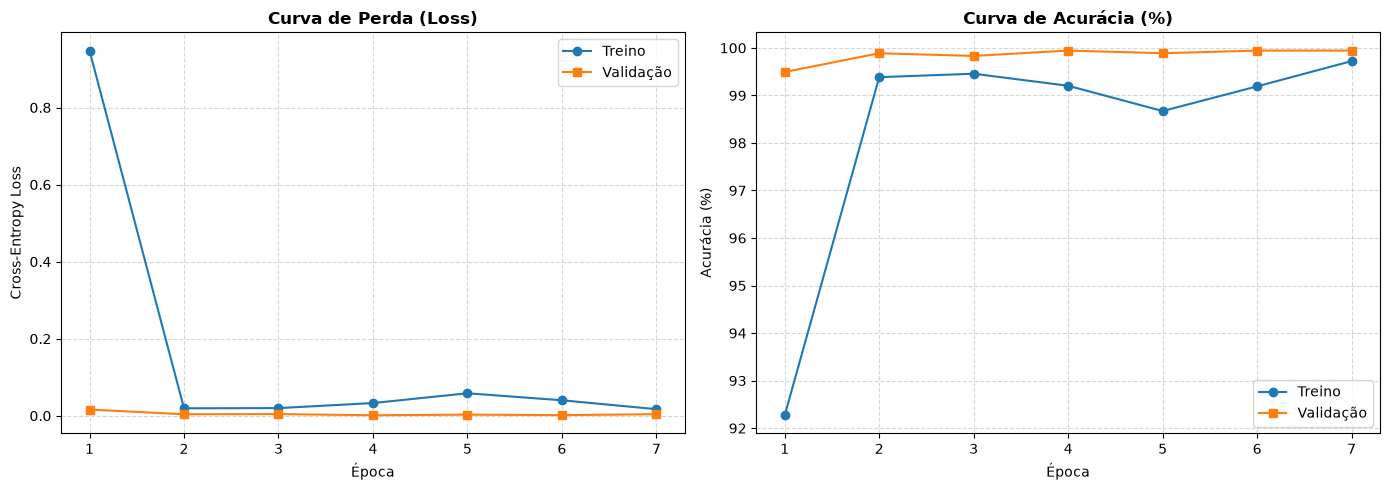

In [5]:
epocas_eixo = range(1, NUM_EPOCHS + 1)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Perda (Loss)
axs[0].plot(epocas_eixo, historico['train_loss'], label='Treino', marker='o')
axs[0].plot(epocas_eixo, historico['val_loss'], label='Validação', marker='s')
axs[0].set_title('Curva de Perda (Loss)', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Cross-Entropy Loss')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico de Acurácia
axs[1].plot(epocas_eixo, historico['train_acc'], label='Treino', marker='o')
axs[1].plot(epocas_eixo, historico['val_acc'], label='Validação', marker='s')
axs[1].set_title('Curva de Acurácia (%)', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Acurácia (%)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Avaliação Final no Conjunto de Teste (Inédito)

In [6]:
modelo.eval()
todas_predicoes = []
todos_rotulos = []

bar_teste = tqdm(test_loader, desc='Avaliando Conjunto de Teste', leave=False)
with torch.no_grad():
    for imagens, rotulos in bar_teste:
        imagens = imagens.to(device)
        saidas = modelo(imagens)
        _, preditos = torch.max(saidas, 1)
        
        todas_predicoes.extend(preditos.cpu().numpy())
        todos_rotulos.extend(rotulos.numpy())

todas_predicoes = np.array(todas_predicoes)
todos_rotulos = np.array(todos_rotulos)

acuracia_teste = (todas_predicoes == todos_rotulos).mean() * 100.0
print(f'=== ACURÁCIA FINAL NO CONJUNTO DE TESTE: {acuracia_teste:.2f}% ===\n')

# Relatório de Classificação detalhado por classe
print('Relatório de Classificação:')
print(classification_report(todos_rotulos, todas_predicoes, target_names=classes, digits=4))

Avaliando Conjunto de Teste:   0%|          | 0/56 [00:00<?, ?it/s]

=== ACURÁCIA FINAL NO CONJUNTO DE TESTE: 99.89% ===

Relatório de Classificação:
              precision    recall  f1-score   support

        ball     0.9953    1.0000    0.9977       426
  inner_race     1.0000    0.9977    0.9988       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    0.9977    0.9988       427

    accuracy                         0.9989      1776
   macro avg     0.9988    0.9988    0.9988      1776
weighted avg     0.9989    0.9989    0.9989      1776



## 7. Matriz de Confusão

In [ ]:
cm = confusion_matrix(todos_rotulos, todas_predicoes)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=classes, yticklabels=classes,
       title='Matriz de Confusão — Diagnóstico de Falhas (CNN)',
       ylabel='Classe Real',
       xlabel='Classe Predita')

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# Preencher os valores numéricos nas células da matriz
threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black')

plt.tight_layout()
plt.show()